# Preprocessing Pipeline

This notebook builds a reusable scikit-learn preprocessing pipeline for the WNBA player valuation project.

It ingests the same raw CSVs used in EDA, feature engineering, and feature selection, applies all transformations in a reproducible way, and exports a model-ready dataframe.

**Pipeline structure:**
1. Data loading & cleaning (same as all other notebooks)
2. Feature engineering (contract flags, role, efficiency, team context, interactions)
3. Feature selection (consensus features from SelectKBest, Lasso, and Random Forest)
4. Preprocessing pipeline (imputation: Scaling for numerical and OHE for categorical)
5. Export model-ready arrays and the fitted pipeline

In [36]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA


## 1. Data Loading & Cleaning

Identical to the preprocessing block used across all other project notebooks.

In [19]:
repo = Path.cwd().parent
data_dir = repo / "data" / "raw"

adv     = pd.read_csv(data_dir / "2025_advanced.csv")
per     = pd.read_csv(data_dir / "2025_per_game.csv")
tot     = pd.read_csv(data_dir / "2025_totals.csv")
sal     = pd.read_csv(data_dir / "salary_2025.csv")
teamadv = pd.read_csv(data_dir / "2025_advanced-team.csv")
stand   = pd.read_csv(data_dir / "2025_wnba_standings.csv")


def clean_col(name):
    text = str(name).strip().lower()
    text = text.replace("2025 salary", "salary")
    text = text.replace("2025 signing", "signing")
    text = text.replace("%", "pct")
    text = re.sub(r"[^0-9a-z]+", "_", text)
    return text.strip("_")


def clean_df(df):
    df.columns = [clean_col(col) for col in df.columns]
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].astype(str).str.strip().replace({"": np.nan, "—": np.nan, "nan": np.nan})
    return df


adv, per, tot = clean_df(adv), clean_df(per), clean_df(tot)
sal, teamadv, stand = clean_df(sal), clean_df(teamadv), clean_df(stand)

sal["salary"] = pd.to_numeric(sal["salary"], errors="coerce")

teammap = {
    "Atlanta Dream": "ATL",       "Chicago Sky": "CHI",
    "Connecticut Sun": "CON",     "Dallas Wings": "DAL",
    "Golden State Valkyries": "GSV", "Indiana Fever": "IND",
    "Las Vegas Aces": "LVA",      "Los Angeles Sparks": "LAS",
    "Minnesota Lynx": "MIN",      "New York Liberty": "NYL",
    "Phoenix Mercury": "PHO",     "Seattle Storm": "SEA",
    "Washington Mystics": "WAS",
}

teamadv["team"] = teamadv["team"].str.replace("*", "", regex=False).str.strip().map(teammap)
stand["team_name"] = stand["team_name"].str.replace("*", "", regex=False).str.strip().map(teammap)

teamdf   = teamadv.merge(stand, left_on="team", right_on="team_name", how="left", suffixes=("_adv", "_stand"))
playerdf = per.merge(adv, on=["player", "team", "pos", "g", "mp"], how="outer")
playerdf = playerdf.merge(tot, on=["player", "team", "pos", "g", "mp", "gs"], how="outer")

name_fix = {
    "Anastasiia Kosu": "Anastasiia Olairi Kosu",
    "Janelle SalaÃ¼n": "Janelle Salaun",
    "LeÃ¯la Lacan": "Leila Lacan",
    "Luisa GeiselsÃ¶der": "Luisa Geiselsoder",
    "Mamignan TourÃ©": "Mamignan Touré",
    "MariÃ¨me Badiane": "Marième Badiane",
    "Te-Hina PaoPao": "Te-Hina Paopao",
    "Sika KonÃ©": "Sika Kone",
}
playerdf["player"] = playerdf["player"].replace(name_fix)

final_df = sal.merge(playerdf, on="player", how="inner", suffixes=("_sal", ""))
final_df = final_df.merge(teamdf, on="team", how="left")
final_df = final_df.drop(columns=["dummy_x", "dummy_y"], errors="ignore")

print(f"Merged dataset shape: {final_df.shape}")
final_df.head(3)

Merged dataset shape: (224, 121)


,player,salary,signing,g_sal,gs_sal,min,pts_sal,fgm,fga_sal,fgpct,...,opp_efg_pct,opp_tov_pct,drb_pct,opp_ft_rate,arena_name,team_name,wins_stand,losses_stand,win_loss_pct,gb
0,A'ja Wilson,200000,RFA,40,40,31.2,23.4,8.3,16.4,50.5%,...,0.489,14.1,74.5,0.199,NaN,LVA,30.0,14.0,0.682,4.0
1,Napheesa Collier,214284,NaN,33,33,32.3,22.9,8.3,15.7,53.1%,...,0.481,15.9,74.1,0.178,NaN,MIN,34.0,10.0,0.773,NaN
2,Kelsey Mitchell,269244,Core,44,44,31.4,20.2,7.2,15.7,45.6%,...,0.503,16.0,75.7,0.233,NaN,IND,24.0,20.0,0.545,10.0


## 2. Feature Engineering

Reproduces all engineered features from `feature_engineering.ipynb`.
Grouped into: contract flags, role, efficiency (per-40), team context, and interaction features.

In [ ]:
def div(a, b):
    return np.where(pd.Series(b).astype(float) != 0, a / b, np.nan)


#Contract features
def get_group(value):
    if pd.isna(value):
        return "unknown"
    value = str(value).strip().lower()
    if "rookie" in value:
        return "rookie"
    if "hardship" in value or "susp" in value:
        return "hardship"
    if value in ["ufa", "rfa", "core"]:
        return "veteran"
    if value in ["udfa", "reserved"]:
        return "controlled"
    return "other"


final_df["group"]         = final_df["signing"].apply(get_group)
final_df["rookie_flag"]   = (final_df["group"] == "rookie").astype(int)
final_df["hardship_flag"] = (final_df["group"] == "hardship").astype(int)
final_df["vet_flag"]      = (final_df["group"] == "veteran").astype(int)
final_df["unknown_flag"]  = (final_df["group"] == "unknown").astype(int)

# Role features
season_games = 44
final_df["avail_rate"] = final_df["g"] / season_games
final_df["start_rate"] = np.where(final_df["g"] > 0, final_df["gs"] / final_df["g"], 0)
final_df["team_min"]   = final_df["mp"] / season_games
final_df["starter"]    = (final_df["start_rate"] >= 0.5).astype(int)
final_df["rotation"]   = (final_df["mp_per_g"] >= 15).astype(int)

# Per 40 minute efficiency features
per40 = div(40, final_df["mp_per_g"])

final_df["pts40"]      = final_df["pts_per_g"] * per40
final_df["ast40"]      = final_df["ast_per_g"] * per40
final_df["reb40"]      = final_df["trb_per_g"] * per40
final_df["stocks"]     = final_df["stl_per_g"] + final_df["blk_per_g"]
final_df["stocks40"]   = final_df["stocks"]    * per40
final_df["pps"]        = div(final_df["pts_per_g"],
                              final_df["fga_per_g"] + 0.44 * final_df["fta_per_g"])
final_df["ft_rate"]    = div(final_df["fta_per_g"],  final_df["fga_per_g"])
final_df["three_rate"] = div(final_df["fg3a_per_g"], final_df["fga_per_g"])
final_df["ast_tov"]    = div(final_df["ast_per_g"],  final_df["tov_per_g"])
final_df["ws_game"]    = div(final_df["ws"],  final_df["g"])
final_df["ws40"]       = div(final_df["ws"],  final_df["mp"]) * 40

# Team context features
if "ts_pct_x" in final_df.columns and "ts_pct_y" in final_df.columns:
    final_df["ts_diff"]  = final_df["ts_pct_x"] - final_df["ts_pct_y"]
else:
    final_df["ts_diff"]  = np.nan

if "efg_pct_x" in final_df.columns and "efg_pct_y" in final_df.columns:
    final_df["efg_diff"] = final_df["efg_pct_x"] - final_df["efg_pct_y"]
else:
    final_df["efg_diff"] = np.nan

strength_cols = [c for c in ["win_loss_pct", "net_rtg", "srs"] if c in final_df.columns]
if strength_cols:
    temp = final_df[strength_cols].apply(pd.to_numeric, errors="coerce")
    temp = temp.fillna(temp.median())
    temp = (temp - temp.mean()) / temp.std(ddof=0).replace(0, 1)
    final_df["team_power"] = temp.mean(axis=1)
else:
    final_df["team_power"] = np.nan

# Interaction features
final_df["ws_rookie"]    = final_df["ws"] * final_df["rookie_flag"]
final_df["ws_vet"]       = final_df["ws"] * final_df["vet_flag"]
final_df["ws_hardship"]  = final_df["ws"] * final_df["hardship_flag"]
final_df["pts_rookie"]   = final_df["pts_per_g"] * final_df["rookie_flag"]
final_df["pts_vet"]      = final_df["pts_per_g"] * final_df["vet_flag"]
final_df["pts_hardship"] = final_df["pts_per_g"] * final_df["hardship_flag"]

# PCA summary features
pca_source_cols = [c for c in ["mp", "pts", "fg", "fga", "ft", "trb", "ast", "ws", "pts40", "ast40"]
                   if c in final_df.columns]

pca_data = final_df[pca_source_cols].apply(pd.to_numeric, errors="coerce")
pca_data = pca_data.fillna(pca_data.median())
pca_data_scaled = StandardScaler().fit_transform(pca_data)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(pca_data_scaled)
final_df["pca1"] = pca_result[:, 0]
final_df["pca2"] = pca_result[:, 1]

# Defragment after many column assignments
final_df = final_df.copy()

print(f"Dataset shape after feature engineering: {final_df.shape}")
print("New features added: contract flags, role, per-40 efficiency, team context, interactions, PCA")


Dataset shape after feature engineering: (224, 152)
New features added: contract flags, role, per-40 efficiency, team context, interactions, PCA


## 3. Feature Selection on Engineered Dataset

- Run SelectKBest, LassoCV, and Random Forest importances
- Keep features that appear in at least 2 of 3 methods
- This becomes the final feature list passed to the preprocessor

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Prepare full feature matrix (all raw + engineered numeric columns)
EXCLUDE = {"salary", "player", "team_name", "arena_name", "dummy", "dummy_team",
           "signing", "group", "iso_outlier_signal"}  # drop target, IDs, categoricals

model_df = final_df.dropna(subset=["salary"]).copy()
X_all = model_df.select_dtypes(include=np.number).drop(
            columns=[c for c in EXCLUDE if c in model_df.columns], errors="ignore")
y_sel = model_df["salary"]

print(f"Full feature matrix: {X_all.shape}  ({X_all.shape[1]} features, {X_all.shape[0]} players)")


Full feature matrix: (224, 121)  (121 features, 224 players)


In [ ]:
# Impute before selection methods that cannot handle NaNs
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X_all), columns=X_all.columns)

# Method 1: SelectKBest
k = 20
kbest = SelectKBest(mutual_info_regression, k=k)
kbest.fit(X_imp, y_sel)
kbest_features = set(X_all.columns[kbest.get_support()])
print(f"SelectKBest top {k}: {sorted(kbest_features)}")


SelectKBest top 20: ['avail_rate', 'blk', 'fg', 'fg2', 'fg2_per_g', 'fg2a', 'fg_per_g', 'fga', 'ft', 'fta', 'g', 'g_sal', 'mp', 'pca1', 'pf', 'pts', 'pts_per_g', 'pts_vet', 'team_min', 'tov']


In [ ]:
# Method 2: LassoCV
lasso_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("lasso",   LassoCV(cv=5, random_state=42, max_iter=10000)),
])
lasso_pipe.fit(X_all, y_sel)

lasso_model = lasso_pipe.named_steps["lasso"]
lasso_features = set(X_all.columns[lasso_model.coef_ != 0])
print(f"Lasso selected {len(lasso_features)} features: {sorted(lasso_features)}")


Lasso selected 29 features: ['ast_pct', 'ast_tov', 'avail_rate', 'blk_pct', 'def_rtg_x', 'def_rtg_y', 'drb_pct', 'dws', 'fg3a', 'fg_pct_y', 'fga', 'ft_per_g', 'ft_rate', 'fta', 'fta_per_fga_pct_y', 'g', 'hardship_flag', 'opp_ft_rate', 'orb_pct_y', 'pace', 'pts_rookie', 'pts_vet', 'rotation', 'start_rate', 'tov_pct_x', 'trb_pct', 'unknown_flag', 'ws_hardship', 'ws_rookie']


In [ ]:
# Method 3: Random Forest importances
rf_sel = RFR(n_estimators=200, min_samples_leaf=3, random_state=42)
rf_sel.fit(X_imp, y_sel)

importances = pd.Series(rf_sel.feature_importances_, index=X_all.columns)
rf_features = set(importances.nlargest(20).index)
print(f"RF top 20: {sorted(rf_features)}")


RF top 20: ['avail_rate', 'blk', 'fg', 'fg_per_g', 'fga', 'ft', 'g', 'g_sal', 'gs', 'mp', 'opp_tov_pct', 'pca1', 'pf', 'pts', 'pts_rookie', 'pts_vet', 'start_rate', 'team_min', 'tov', 'ws_rookie']


In [37]:
# Consensus: keep features selected by at least 2 of 3 methods
from collections import Counter

vote_counter = Counter()
for feat_set in [kbest_features, lasso_features, rf_features]:
    for f in feat_set:
        vote_counter[f] += 1

consensus_features = sorted([f for f, votes in vote_counter.items() if votes >= 2])

print(f"\nConsensus features (2 or more votes): {len(consensus_features)}")
print(consensus_features)

# Vote summary table
vote_df = pd.DataFrame([
    {
        "feature":     f,
        "kbest":       int(f in kbest_features),
        "lasso":       int(f in lasso_features),
        "rf":          int(f in rf_features),
        "total_votes": votes,
    }
    for f, votes in vote_counter.most_common()
])
print("\nFull vote table:")
display(vote_df)



Consensus features (2 or more votes): 19
['avail_rate', 'blk', 'fg', 'fg_per_g', 'fga', 'ft', 'fta', 'g', 'g_sal', 'mp', 'pca1', 'pf', 'pts', 'pts_rookie', 'pts_vet', 'start_rate', 'team_min', 'tov', 'ws_rookie']

Full vote table:


,feature,kbest,lasso,rf,total_votes
0,pts_vet,1,1,1,3
1,fga,1,1,1,3
2,g,1,1,1,3
3,avail_rate,1,1,1,3
4,team_min,1,0,1,2
5,g_sal,1,0,1,2
6,fg_per_g,1,0,1,2
7,pf,1,0,1,2
8,mp,1,0,1,2
9,pca1,1,0,1,2


In [ ]:
# Add back categorical features not handled by numeric selection
categorical_features = ["group"]   # contract type — always include

# Final combined feature list
feature_cols = consensus_features + categorical_features

print(f"Final feature count: {len(feature_cols)} ({len(consensus_features)} numeric + {len(categorical_features)} categorical)")


Final feature count: 20 (19 numeric + 1 categorical)


### Feature Diagnostics

Three quick checks before passing the feature list to the preprocessor:
1. Are `g` and `g_sal` duplicates?
2. Is `pf` redundant with `mp`?
3. Do raw totals outperform per-40 rate features?


In [38]:
# Check 1: are g and g_sal identical? 
print("g vs g_sal comparison:")
print(final_df[["g", "g_sal"]].head(10))
print(f"\nAre they identical? {(final_df['g'] == final_df['g_sal']).all()}")
print(f"Correlation: {final_df['g'].corr(final_df['g_sal']):.4f}")

# Drop g_sal from consensus if they are identical
if (final_df['g'] == final_df['g_sal']).all():
    consensus_features = [f for f in consensus_features if f != 'g_sal']
    feature_cols = consensus_features + categorical_features
    print("\nDropped g_sal, identical to g")
else:
    print("\nKept both, they differ")


g vs g_sal comparison:
    g  g_sal
0  40     40
1  33     33
2  44     44
3  43     43
4  36     36
5  44     44
6  42     42
7  31     31
8  44     44
9  38     38

Are they identical? True
Correlation: 1.0000

Dropped g_sal, identical to g


In [39]:
# Check 2: is pf redundant with mp?
if "pf" in final_df.columns:
    pf_mp_corr  = final_df["pf"].corr(final_df["mp"])
    pf_sal_corr = final_df["pf"].corr(final_df["salary"])

    print(f"pf vs mp correlation:     {pf_mp_corr:.4f}")
    print(f"pf vs salary correlation: {pf_sal_corr:.4f}")

    if abs(pf_mp_corr) > abs(pf_sal_corr):
        consensus_features = [f for f in consensus_features if f != "pf"]
        feature_cols = consensus_features + categorical_features
        print("\nDropped pf, more correlated with mp than salary (redundant)")
    else:
        print("\nKept pf, has independent signal with salary")


pf vs mp correlation:     0.9093
pf vs salary correlation: 0.6139

Dropped pf, more correlated with mp than salary (redundant)


In [43]:
# Check 3: raw totals vs per-40 rates
comparisons = [
    ("pts",  "pts40"),
    ("fg",   "fg_per_g"),
    ("mp",   "ws40"),
    ("ws",   "ws_game"),
]

print("Correlation with salary: raw totals vs rate-adjusted")
print(f"{'Feature':<12} {'Corr with salary':>18}")
print("-" * 32)
for raw, rate in comparisons:
    for col in [raw, rate]:
        if col in final_df.columns:
            corr = final_df[col].corr(final_df["salary"])
            print(f"{col:<12} {corr:>18.4f}")
    print()

print(f"\nFinal feature list ({len(feature_cols)} total):")
print(feature_cols)


Correlation with salary: raw totals vs rate-adjusted
Feature        Corr with salary
--------------------------------
pts                      0.7097
pts40                    0.4605

fg                       0.6982
fg_per_g                 0.6406

mp                       0.6866
ws40                     0.4002

ws                       0.5976
ws_game                  0.5467


Final feature list (18 total):
['avail_rate', 'blk', 'fg', 'fg_per_g', 'fga', 'ft', 'fta', 'g', 'mp', 'pca1', 'pts', 'pts_rookie', 'pts_vet', 'start_rate', 'team_min', 'tov', 'ws_rookie', 'group']


## 4. Build the Preprocessing Pipeline

The pipeline has two parallel branches joined by a `ColumnTransformer`:

- **Numeric branch:** median imputation (standard scaling)
- **Categorical branch:** constant imputation (`"Unknown"`) -> one-hot encoding

The pipeline is fit on the full labeled dataset here. For actual model training, call `pipeline.fit_transform(X_train)` and `pipeline.transform(X_test)` separately.

In [42]:
# Prepare modeling dataframe
model_df = final_df.dropna(subset=["salary"]).copy()

X = model_df[feature_cols]
y = model_df["salary"]

print(f"Rows with salary: {len(model_df)}")
print(f"Feature matrix shape: {X.shape}")

# Identify numeric vs. categorical columns
num_features = [c for c in feature_cols if c not in categorical_features]
cat_features  = [c for c in feature_cols if c in categorical_features]

print(f"\nNumeric features  ({len(num_features)}): {num_features[:5]} ...")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

Rows with salary: 224
Feature matrix shape: (224, 18)

Numeric features  (17): ['avail_rate', 'blk', 'fg', 'fg_per_g', 'fga'] ...
Categorical features (1): ['group']


In [44]:
# Define sub-pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # fill NaNs with column median
    ("scaler",  StandardScaler()),                   # zero mean, unit variance
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),  # fill NaNs
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline,     num_features),
        ("cat", categorical_pipeline, cat_features),
    ],
    remainder="drop",   # drop any column not explicitly listed
)

print("Preprocessing pipeline defined.")
print(preprocessor)

Preprocessing pipeline defined.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['avail_rate', 'blk', 'fg', 'fg_per_g', 'fga',
                                  'ft', 'fta', 'g', 'mp', 'pca1', 'pts',
                                  'pts_rookie', 'pts_vet', 'start_rate',
                                  'team_min', 'tov', 'ws_rookie']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_u

In [45]:
# Fit and transform
X_processed = preprocessor.fit_transform(X)

# Recover feature names after OHE expansion
ohe_feature_names = []
if cat_features:
    ohe = preprocessor.named_transformers_["cat"]["encoder"]
    ohe_feature_names = ohe.get_feature_names_out(cat_features).tolist()

processed_feature_names = num_features + ohe_feature_names

X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

print(f"Output shape: {X_processed_df.shape}")
print(f"No missing values remaining: {X_processed_df.isna().sum().sum() == 0}")
X_processed_df.head(3)

Output shape: (224, 22)
No missing values remaining: True


,avail_rate,blk,fg,fg_per_g,fga,ft,fta,g,mp,pca1,...,pts_vet,start_rate,team_min,tov,ws_rookie,group_controlled,group_hardship,group_rookie,group_unknown,group_veteran
0,0.908943,5.576746,3.235080,3.151330,2.828263,4.581786,4.308942,0.908943,1.625888,3.313517,...,3.781740,1.535455,1.625888,1.662930,-0.270577,0.0,0.0,0.0,0.0,1.0
1,0.394979,2.698425,2.498941,3.151330,1.987885,2.538068,2.169560,0.394979,1.192264,2.340737,...,-0.768850,1.535455,1.192264,1.106134,-0.270577,0.0,0.0,0.0,1.0,0.0
2,1.202636,-0.248426,3.015530,2.555361,3.026352,2.406215,2.511142,1.202636,1.945150,2.392742,...,3.159437,1.535455,1.945150,1.368156,-0.270577,0.0,0.0,0.0,0.0,1.0


## 5. Sanity Check

Quick checks to confirm the pipeline output is reasonable before handing off to modeling.

NaN values in processed matrix: 0

Mean and std of numeric features (should be 0 and 1):
            mean  std
avail_rate  -0.0  1.0
blk         -0.0  1.0
fg           0.0  1.0
fg_per_g     0.0  1.0
fga          0.0  1.0
ft           0.0  1.0
fta          0.0  1.0
g           -0.0  1.0


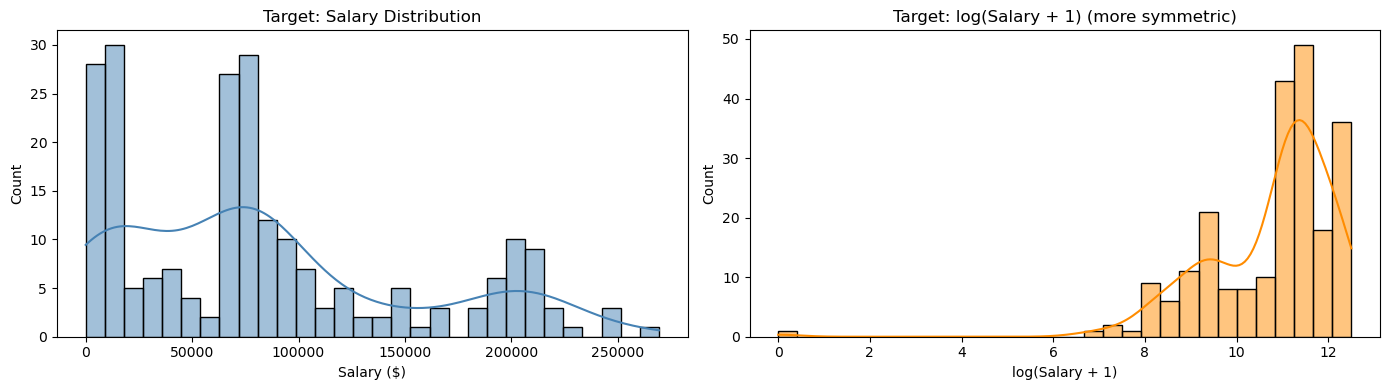

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check 1: no NaNs
nan_count = X_processed_df.isna().sum().sum()
print(f"NaN values in processed matrix: {nan_count}")

# Check 2: numeric columns should have mean 0, std 1
num_check = X_processed_df[num_features].describe().loc[["mean", "std"]].round(2)
print("\nMean and std of numeric features (should be 0 and 1):")
print(num_check.T.head(8))

# Check 3: salary distribution for reference 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y, kde=True, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Target: Salary Distribution")
axes[0].set_xlabel("Salary ($)")

sns.histplot(np.log1p(y), kde=True, bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Target: log(Salary + 1) (more symmetric)")
axes[1].set_xlabel("log(Salary + 1)")

plt.tight_layout()
plt.show()


## Salary Distribution Findings

The two plots above reveal that WNBA salaries are not normally distributed
they form three distinct clusters driven by CBA contract rules:

- **$10k–$20k**: rookie and hardship contract players locked into minimum-scale salaries
- **$70k–$90k**: the main veteran market
- **$200k+**: star players (max contract tier)

The log transformation (right plot) does not fully resolve this into a symmetric 
distribution. The bimodal/trimodal structure is a real feature of the data, not 
just statistical skew. Note that in `KPI_baseline.ipynb`, removing rookie and hardship contracts significantly stabilized MAPE.

**Implications for modeling:**
- A single model predicting across all tiers will struggle to fit all three clusters well
- Consider either log-transforming salary as the target variable (maybe not), or handling contract 
  tiers separately during modeling (this option seems better)

## 6. Export

Save the fitted pipeline and the processed arrays so other notebooks can load them directly without re-running everything.

In [35]:
output_dir = repo / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Save fitted pipeline
joblib.dump(preprocessor, output_dir / "preprocessor.pkl")
print(f"Saved: {output_dir / 'preprocessor.pkl'}")

# Save processed feature matrix
X_processed_df.to_csv(output_dir / "X_processed.csv", index=False)
print(f"Saved: {output_dir / 'X_processed.csv'}")

# Save target vector
y.reset_index(drop=True).to_csv(output_dir / "y_salary.csv", index=False)
print(f"Saved: {output_dir / 'y_salary.csv'}")

# Save the full engineered dataframe (useful for downstream analysis)
model_df.to_csv(output_dir / "model_ready.csv", index=False)
print(f"Saved: {output_dir / 'model_ready.csv'}")

# Save feature name list
pd.Series(processed_feature_names).to_csv(output_dir / "feature_names.csv", index=False, header=["feature"])
print(f"Saved: {output_dir / 'feature_names.csv'}")

Saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed/preprocessor.pkl
Saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed/X_processed.csv
Saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed/y_salary.csv
Saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed/model_ready.csv
Saved: /Users/aklima/GitHub/summer26-wnba-player-valuation/data/processed/feature_names.csv


## 7. How to Load the Pipeline in Another Notebook

```python
import joblib
import pandas as pd
from pathlib import Path

output_dir = Path.cwd().parent / "data" / "processed"

# Load the fitted pipeline
preprocessor = joblib.load(output_dir / "preprocessor.pkl")

# Load processed features and target
X = pd.read_csv(output_dir / "X_processed.csv")
y = pd.read_csv(output_dir / "y_salary.csv")["salary"]

# Or to transform new data with the same pipeline:
# X_new_processed = preprocessor.transform(X_new[feature_cols])
```